<a href="https://colab.research.google.com/github/vidhu-psit/MachineLearning/blob/master/DeepLearning/11_Weight_initialization_and_Optimisers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## References

symmetry + weight init - https://towardsdatascience.com/neural-network-breaking-the-symmetry-e04f963395dd

weight init (applied roots): https://www.appliedaicourse.com/lecture/11/applied-machine-learning-online-course/3388/weight-initialization/8/module-8-neural-networks-computer-vision-and-deep-learning

vanishing / exploding gradient:  https://www.youtube.com/watch?v=qhXZsFVxGKo&list=PLkDaE6sCZn6Hn0vK8co82zjQtt3T2Nkqc&index=11

random weight init: https://youtube.com/watch?v=6by6Xas_Kho

weight init in deep NN: https://www.youtube.com/watch?v=s2coXdufOzE&list=PLkDaE6sCZn6Hn0vK8co82zjQtt3T2Nkqc&index=11


## **Content**

- 24Seven Business Case

- Random weight init

- Exploding Gradients

  - [True options](https://www.scaler.com/hire/test/problem/20513/)
  - [Vanishing gradients](https://www.scaler.com/hire/test/problem/20515/)


- Weight Intialization
  - [Gradient optimization techniques](https://www.scaler.com/hire/test/problem/20534/)
  - [Frequency of updates](https://www.scaler.com/hire/test/problem/21243/)
  - [Loss in SGD](https://www.scaler.com/hire/test/problem/21530/)

  - [Weights initialized to zero](https://www.scaler.com/hire/test/problem/21099/)


- Exponentially Moving Avg

- GD with momentum
  - [Updated value of weight II](https://www.scaler.com/hire/test/problem/21242/)
  - [Momentum based GD](https://www.scaler.com/hire/test/problem/21531/)
  - [Update vector](https://www.scaler.com/hire/test/problem/21570/) (check once --> submit button shows issue)
  - [Momentum based gradient descent](https://www.scaler.com/hire/test/problem/17867/)

- RMSprop
- Adam
- Learning Rate Decay
  - [Learning rate](https://www.scaler.com/hire/test/problem/21611/)
- Simulation for Adam,RMSprop, GD with momentum

#**Business Case**

You are working at **24Seven**, which has different stores buying various products. Based on the purchase history :
- you want to divide the stores into classes for better inventory management and customer handling.



Lets now load the data


In [ ]:
!gdown 1ZdhRqYv-JizWV6DxO6C4R_k1kxPhmlF2
#https://drive.google.com/file/d/1ZdhRqYv-JizWV6DxO6C4R_k1kxPhmlF2/view?usp=sharing

Downloading...
From: https://drive.google.com/uc?id=1ZdhRqYv-JizWV6DxO6C4R_k1kxPhmlF2
To: /content/multiclass.csv
100% 14.6k/14.6k [00:00<00:00, 19.6MB/s]


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**Data Description:**


| Id | Features | Description |
| :-- | :--| :--|
|01| **Region** | Region of the store (1: Less purchase 2: frequent purchase 3: high purchase|
|02| **Fresh** | How many fresh items are brought |
|03|**Milk**| How many units of Milk is purchased |
|04|**Grocery**|Units of Grocery bought for the store |
|05|**Frozen**|Frozen items purchased |
|06|**Detergents_Paper**|Unit of Detergents and paper bought |
|07|**Delicassen**|Food related items |
|08|**class**| Type/Category of the Store (1 ,2 , 3)|


In [ ]:
df = pd.read_csv('multiclass.csv')

df.head()

,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,class
0,3,12669,9656,7561,214,2674,1338,2
1,3,7057,9810,9568,1762,3293,1776,2
2,3,6353,8808,7684,2405,3516,7844,2
3,3,13265,1196,4221,6404,507,1788,1
4,3,22615,5410,7198,3915,1777,5185,1


Total Number of samples and features of the data:
<center>

| Records | Features |
| :-- | :-- |
| 440 | 8 |

In [ ]:
df.shape

(440, 8)

#EDA

<font color='red'>Instructor Note</font>
- Covered in PRERead

Converting ```Region``` a **Categorical data** to  ```One Hot Encoding``` matrix



In [ ]:
df = pd.get_dummies(df, columns = ['Region'])

#storing class label
Y = df['class']
df = pd.get_dummies(df, columns = ['class'])

df.head()

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,Region_1,Region_2,Region_3,class_1,class_2,class_3
0,12669,9656,7561,214,2674,1338,0,0,1,0,1,0
1,7057,9810,9568,1762,3293,1776,0,0,1,0,1,0
2,6353,8808,7684,2405,3516,7844,0,0,1,0,1,0
3,13265,1196,4221,6404,507,1788,0,0,1,1,0,0
4,22615,5410,7198,3915,1777,5185,0,0,1,1,0,0


In [ ]:
X = df.drop(columns=['class_1','class_2','class_3'])
y = df[['class_1','class_2','class_3']]

Visualizing the data using PCA

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# reducing features to just 2 features
pca = PCA(n_components=2)
visual_1 = pca.fit_transform(X)
visual_1.shape

(440, 2)

[0.45961362 0.40517227]


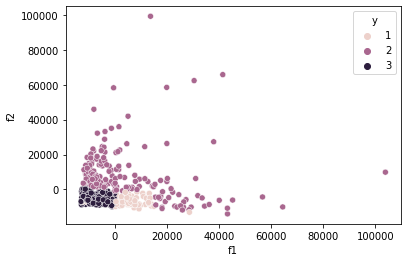

In [ ]:
df2 = pd.DataFrame(visual_1, columns=['f1', 'f2'])
df2['y'] = Y
print(pca.explained_variance_ratio_)
sns.scatterplot(data= df2, x= 'f1',y = 'f2' , hue = 'y')
plt.show()

**Observe**

The data is non-linear, hence to correctly classify the data:
- We will require a deep Neural Network


Splitting Data into Train, Validation and Test Data

In [ ]:
from sklearn.model_selection import train_test_split

X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.1, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.1, random_state=42)

print('Train : ', X_train.shape, y_train.shape)
print('Validation:', X_val.shape, y_val.shape)
print('Test  : ', X_test.shape, y_test.shape)

Train :  (356, 9) (356, 3)
Validation: (40, 9) (40, 3)
Test  :  (44, 9) (44, 3)


Standardizing the data

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)

X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)


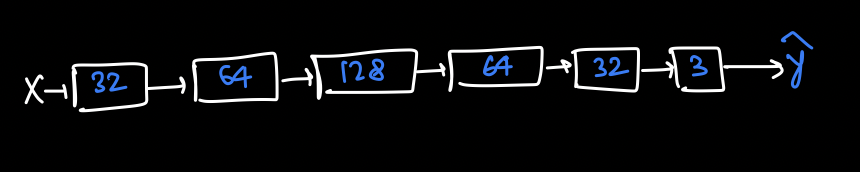

Now that the data is ready, we can implement
- A NN model using [tensorflow keras](https://keras.io/api/)
- By creating 7 layered NN such that:

|Layer| |Descrption|
|:--| |:--|
|**L1**| |Is the Input Layer |
|**L2**| |Contains 32 Neurons|
|**L3**| |Contains 64 Neurons|
|**L4**| |Contains 128 Neurons|
|**L5**| |Contains 64 Neurons |
|**L6**| |Contains 32 Neurons|
|**L7**| |Is the Output Layer |
<br>

**Note:** In Between the layers, we will use:
- ReLU as the Activation function


In [ ]:
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense


# For Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

In [ ]:
def create_baseline():

  model = Sequential([
                    Dense(32, activation="relu",kernel_initializer='glorot_uniform'),
                    Dense(64, activation="relu",kernel_initializer='glorot_uniform'),
                    Dense(128, activation="relu",kernel_initializer='glorot_uniform'),
                    Dense(64, activation="relu",kernel_initializer='glorot_uniform'),
                    Dense(32, activation="relu",kernel_initializer='glorot_uniform'),
                    Dense(3,activation='softmax')])
  return model

In [ ]:
model = create_baseline()

Using ```MiniBatch GD``` as Optimizer

In [ ]:
model.compile(optimizer = tf.keras.optimizers.SGD(),
                loss = tf.keras.losses.CategoricalCrossentropy() )


Training the model with epoch=10 and batch size = 128

In [ ]:
history = model.fit(X_train, y_train, validation_data = (X_val, y_val),  epochs=10, batch_size=128)


Epoch 1/10
3/3 [==============================] - 2s 91ms/step - loss: 1.1166 - val_loss: 1.1014
Epoch 2/10
3/3 [==============================] - 0s 11ms/step - loss: 1.1109 - val_loss: 1.0949
Epoch 3/10
3/3 [==============================] - 0s 11ms/step - loss: 1.1055 - val_loss: 1.0883
Epoch 4/10
3/3 [==============================] - 0s 12ms/step - loss: 1.1004 - val_loss: 1.0820
Epoch 5/10
3/3 [==============================] - 0s 12ms/step - loss: 1.0955 - val_loss: 1.0762
Epoch 6/10
3/3 [==============================] - 0s 11ms/step - loss: 1.0910 - val_loss: 1.0706
Epoch 7/10
3/3 [==============================] - 0s 10ms/step - loss: 1.0865 - val_loss: 1.0650
Epoch 8/10
3/3 [==============================] - 0s 12ms/step - loss: 1.0822 - val_loss: 1.0598
Epoch 9/10
3/3 [==============================] - 0s 11ms/step - loss: 1.0780 - val_loss: 1.0547
Epoch 10/10
3/3 [==============================] - 0s 11ms/step - loss: 1.0739 - val_loss: 1.0497


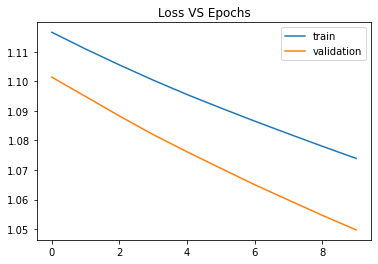

In [ ]:
epochs = history.epoch
loss = history.history["loss"]
val_loss = history.history["val_loss"]


plt.plot(epochs, loss, label="train")
plt.plot(epochs, val_loss, label="validation")

plt.legend()
plt.title("Loss VS Epochs")

plt.show()



**Observe**

After 10 epochs the model still has a very high loss

<br>

#### What should be done to make the model perform better ?

Ans: increase the training epochs of the model

Lets now increase the epoch of model to 200

In [ ]:
history = model.fit(X_train, y_train, validation_data = (X_val, y_val),  epochs=200, batch_size=128, verbose = 0)


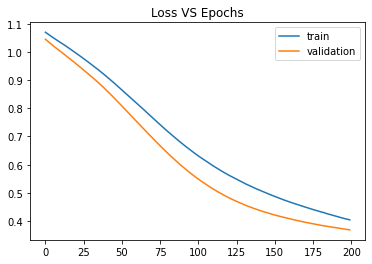

In [ ]:
epochs = history.epoch
loss = history.history["loss"]
val_loss = history.history["val_loss"]


plt.plot(epochs, loss, label="train")
plt.plot(epochs, val_loss, label="validation")

plt.legend()
plt.title("Loss VS Epochs")

plt.show()



**observe**

The model requires 210 epochs:
- For it to have such a low loss

Now imagine if the dataset has 5 million samples:
- The model will require a very high training epoch
- in order for it to reach global minima

This surely will be a huge drawback:
- While deploying the model

**Quiz**

```
If a Gradient Descent Optimizer considers only a single sample per epoch, then it is called ?

1. Stochastic gradient descent
2. Mini- batch gradient descent
3. Gradient descent
```

**Answer**

1. Stochastic gradient descent

**Assessments Covered**
- https://www.scaler.com/hire/test/problem/20534/
- https://www.scaler.com/hire/test/problem/21243/
- https://www.scaler.com/hire/test/problem/21530/


# Exponential Moving Average

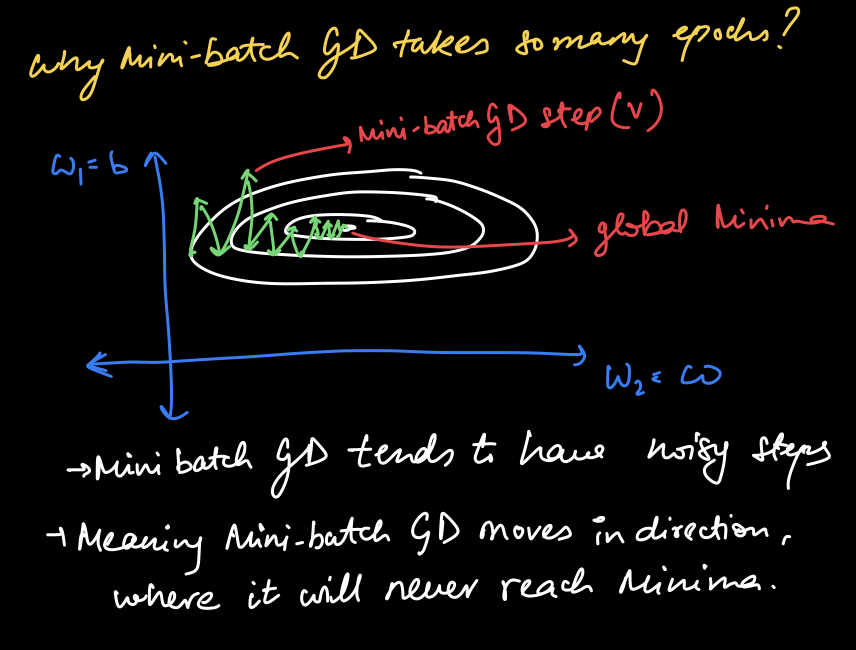

#### Why Mini-Batch GD takes so many epochs ?
Ans: Mini-batch GD takes some steps ($V$) before reaching global minima

In many of these steps, the optimizer
- Tends to move in direction where it will never reach minima
- Hence due to all these noisy steps, the GD takes so many epochs

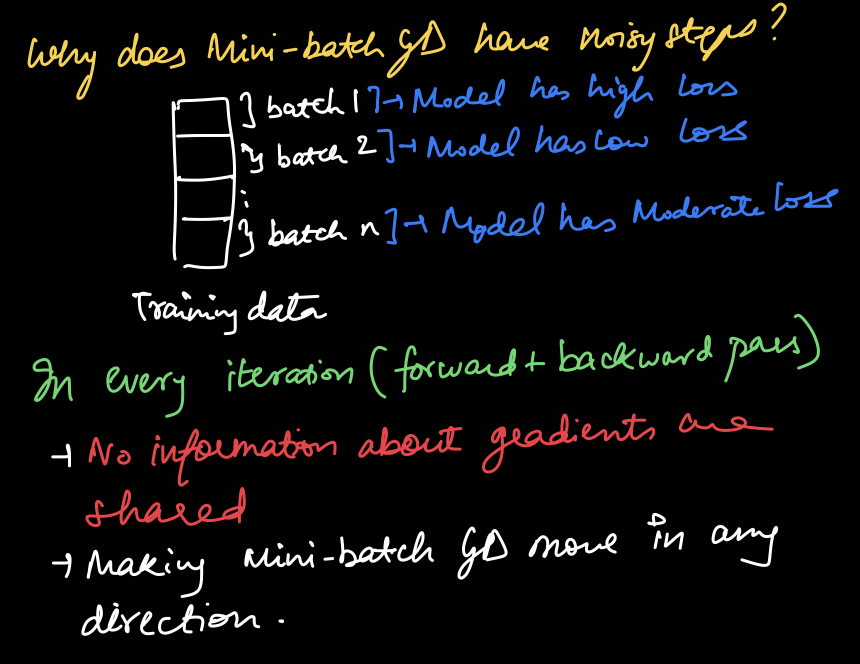

#### Why does mini-Batch GD have noisy steps ?
Ans: Because, training data is divided into batches
- And for some batch the model has very small loss
- while for a few batch, the loss is quite high
- Making the gradients of weights have high, low values
- Thus effecting the step of Mini-Batch GD optimizer

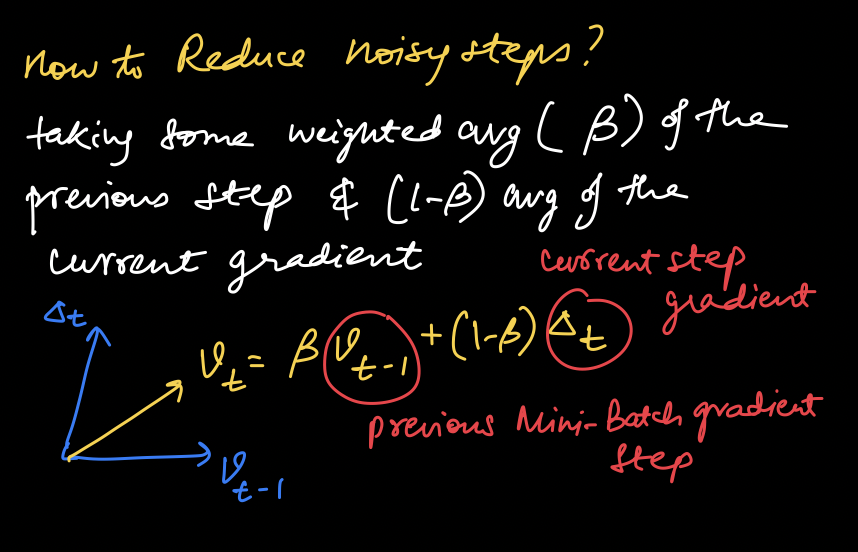



#### How to reduce the number of epochs during training of the model ?

Ans: By decreasing the number of steps ($V$) optimization algorithm takes to reach global minima.

<br>

#### How to reduce the steps $V$ required for the algorithm to reach global minima ?

If we combine these past steps taken by the optimizer:
-  for it to update the direction of step
- such that it moves towards global minima  





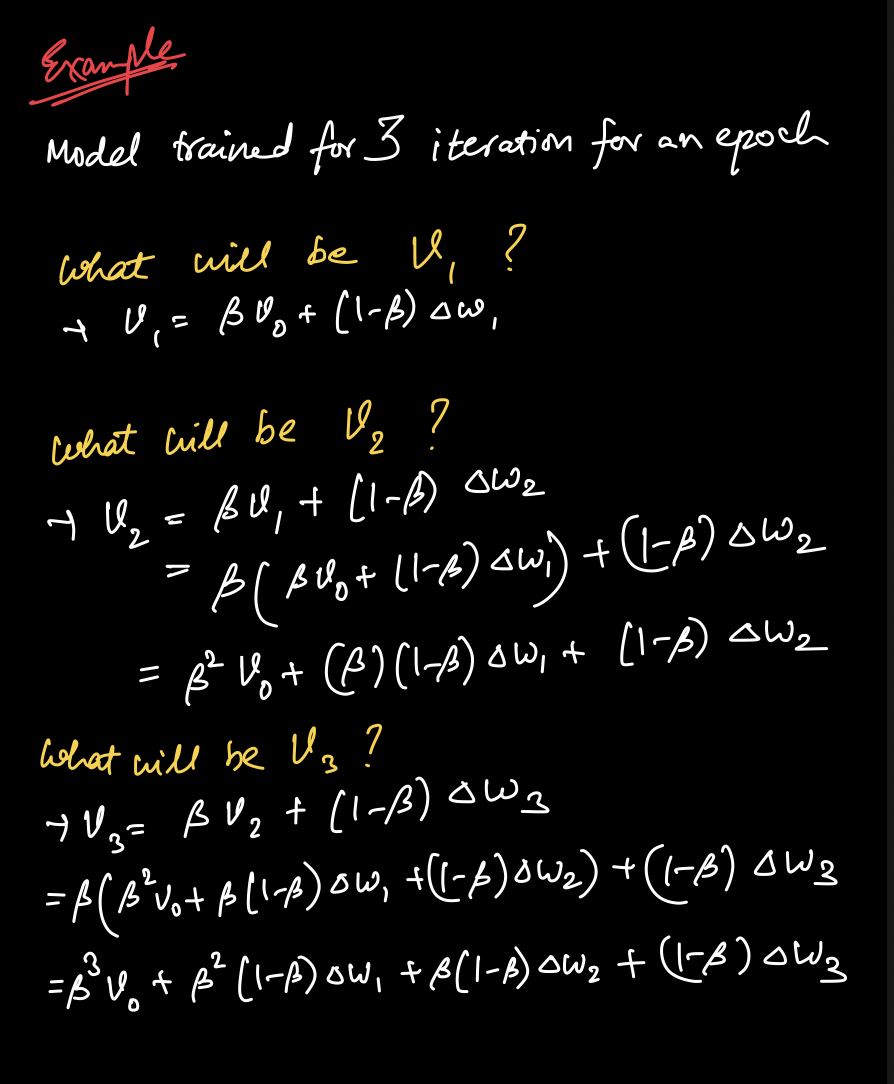

#### Will combining the past steps taken by the optimizer help ?
Ans: Yes, to better understand this lets assume model trained for 3 iterations

Note: 1 iteration = ForwardProp + BackProp

#### What will be the value of $V_1$ ?
Ans: $V_1 = \beta V_0 + (1-\beta) Δ w_1$



#### What will be the value of $V_2$ ?
Ans: $V_2 = \beta V_1 + (1-\beta) Δ w_2$

- $V_2 =\beta^2 V_0 + \beta(1-\beta)Δ w_1+ (1-\beta) Δ w_2 $


#### What will be value of $V_3$ ?

Ans: $V_3 = \beta V_2 + (1-\beta) Δ w_3$

- $V_3 =\beta^3 V_0 + \beta^2(1-\beta)Δ w_1+ \beta(1-\beta) Δ w_2 + (1-\beta) Δ w_3  $




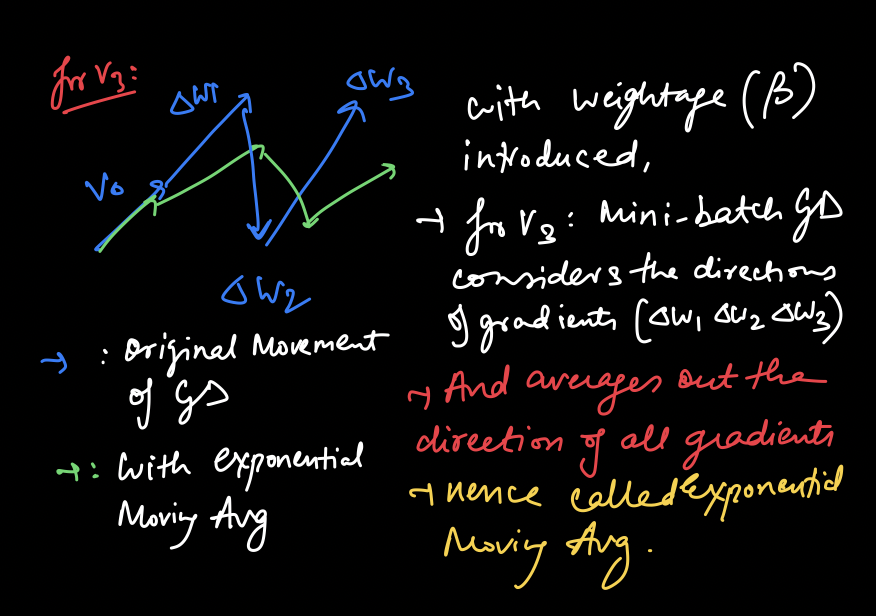


Thus using **Exponential Moving Average**, the optimizer
- updates its direction according to its previous step taken.
- And smoothes out its current direction
- in order to reach global minima faster

**Quiz**

```
if v0 = 0 ,beta = 0.9 and gradient of w0 = 0.1, then what is value of v1 ?

1. 0.01
2. 0.09
3. 0.001

```
**Answer**

1. 0.01

**Explanation**

$v_t = \beta v_{t-1} + (1-\beta) Δw_t$
- $v_1 = 0.9 \times 0 + (0.1) \times (0.1) = 0.01$

**quiz**

```
if GD step in the previous step was at 0.04 with beta = 0.9 and now it is at 0.06, then what is the gradient value ?


1. 0.006
2. 0.036
3. 0.240

```

**Answer**

3. 0.240

**Explanation**

$v_t = \beta v_{t-1} + (1-\beta)  Δw_t$
- $0.06 = 0.9 \times 0.04 + (0.1) \times Δw_t $
- $ \frac{0.06 - 0.036}{0.1} = Δw_t $
- $0.24 = Δw_t$

#Graident Descent with Momentum

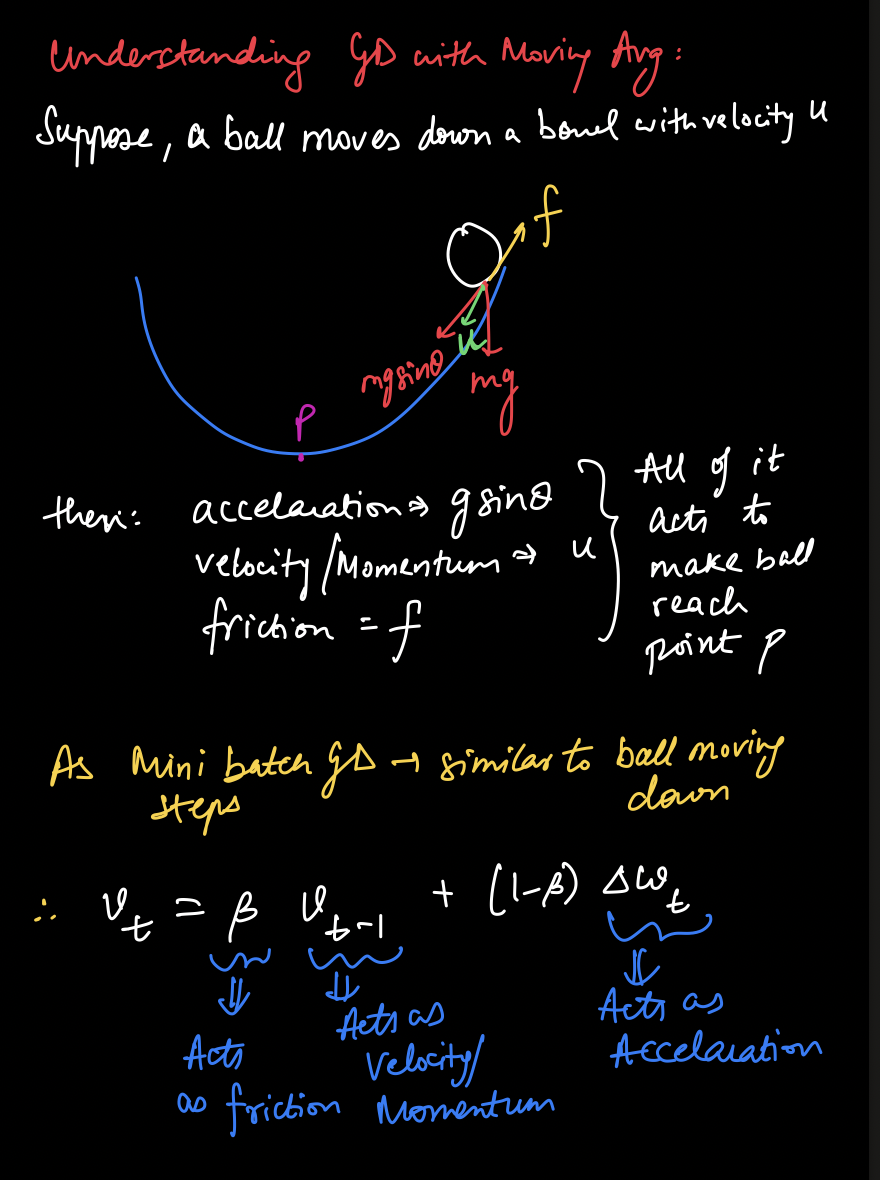

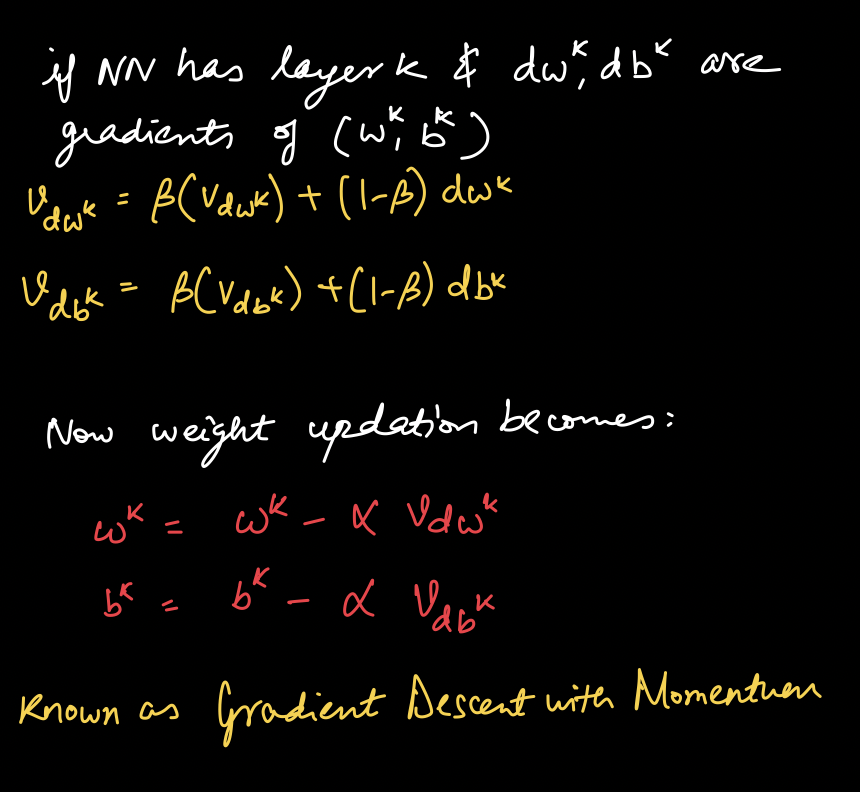

#### How does Gradient Descent implement Exponential Moving Average ?

Ans: for some iteration t and layer $k$ of the NN :
- after finding $dw^k$ and $db^k$,

the exopnential moving average is introduced:
- $V_{dw^k} = β \times V_{dw^k} + (1-β) \times dw^k $

Similarly:

- $V_{db^k} = β \times V_{db^k} + (1-β) \times db^k $

Hence Weight updation with learning rate $α$ becomes:
- $w^k = w^k -\alpha \times V_{dw^k}$

- $b^k = b^k -\alpha \times V_{db^k}$

<br>

**Note:** This approach can be analogous to a ball moving down a hill where:

- the gradients $dw^k $ and $db^k$ acts as acceleration
- the $V_{dw}$ and $V_{db}$ acts as velocity with which the ball is moving
- And the term $β$ acts as friction and helps prevent the ball from speeding up without limit

Hence we can say, as the ball rolls down, it gains **momentum**
- therefore this approach is called **Gradient Descent with Momentum**












Lets now implement Gradient Descent with momentum on our model

In [ ]:
model_gdm = create_baseline()

Using ```MiniBatch GD``` as Optimizer

In [ ]:
model_gdm.compile(optimizer = tf.keras.optimizers.SGD(momentum=0.9),
                loss = tf.keras.losses.CategoricalCrossentropy() )


Training the model with epoch = 50 and batch size = 128

In [ ]:
history = model_gdm.fit(X_train, y_train, validation_data = (X_val, y_val),  epochs=50, batch_size=128, verbose = 0)


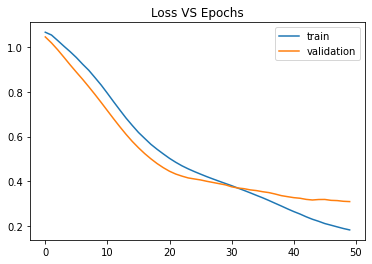

In [ ]:
epochs = history.epoch
loss = history.history["loss"]
val_loss = history.history["val_loss"]


plt.plot(epochs, loss, label="train")
plt.plot(epochs, val_loss, label="validation")

plt.legend()
plt.title("Loss VS Epochs")

plt.show()



**Observe**

Just by using Momentum with Gradient Descent:
- The model was able to perform so much better in just 25 epochs



**Quiz**

```
What is acceleration of a downhill moving ball analogous to in GD with momentum?

1. beta
2. gradient value
3. Gradient descent step (V)

```

**Answer**

2. gradient value

**Quiz**

```
What is weight value, if learning rate = 0.01, V_dw = 0.1 and initial weight value = 1.2?

1. 1.198
2. 1.199
3. 1.200
```

**Answer**

2. 1.199

**Explanation**

$w = w - α \times V_{dw}$
- $w = 1.2 - 0.01 \times 0.1$
- $w = 1.2 - 0.001 = 1.199$

**Assessments Covered**
- https://www.scaler.com/hire/test/problem/21242/
- https://www.scaler.com/hire/test/problem/21531/
- https://www.scaler.com/hire/test/problem/21570/ (check once)
- https://www.scaler.com/hire/test/problem/17867/


# RMSprop

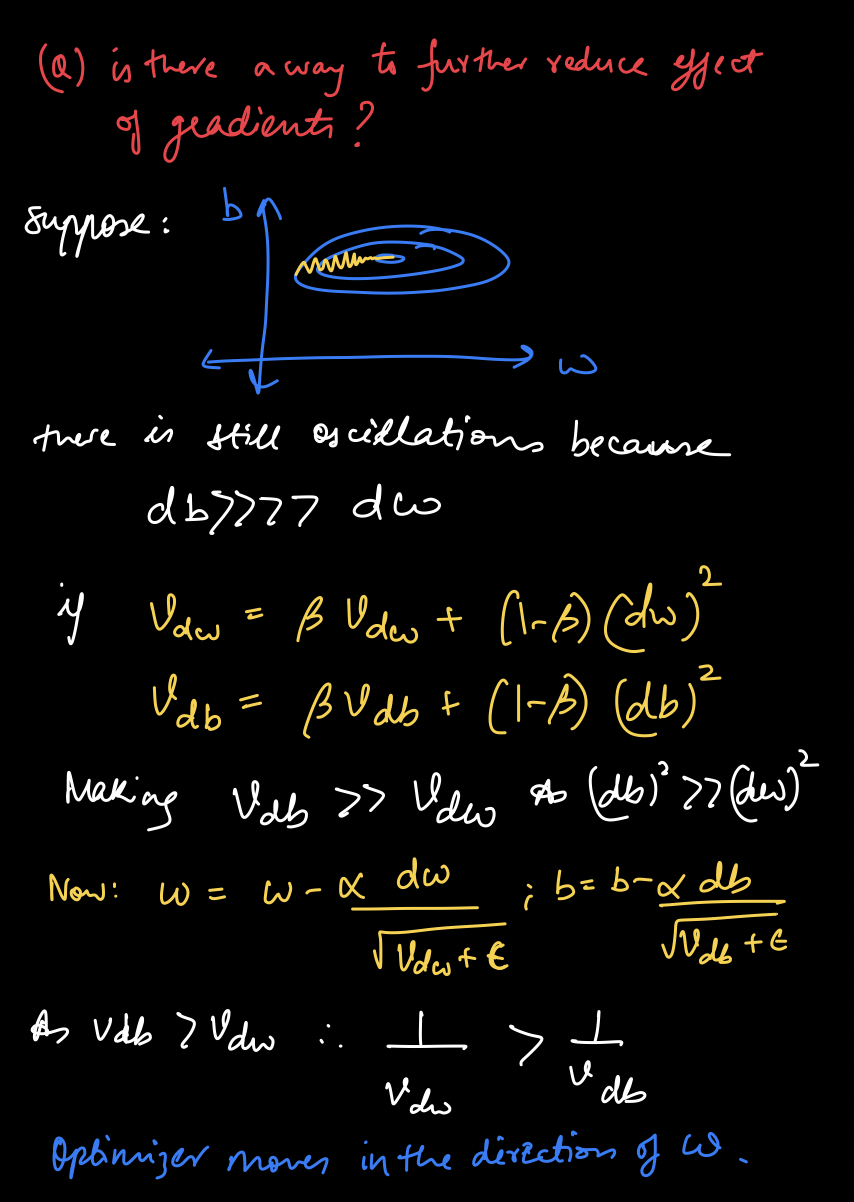

This 25 epochs is still quite high for a real world training data

#### Is there a way to furthur reduce the training epoch for the model ?

Ans: Yes, as we know :
- optimizer tends to move in direction (osciallations) when gradient of weight is greater than the other
- Meaning $ Δb >>> Δw $

Hence to reduce this moving direction, lets say:

On some iteration t, we calculate $V_{dw} $ by squaring the gradients as:
- $V_{dw^k} = \beta V_{dw^k} + (1-β) (dw^k)^2 $
- $V_{db^k} = \beta V_{db^k} + (1-β) (db^k)^2 $


#### How is squaring useful ?
Ans: as gradients in which the optimizer moves is higher then:
- the square of the gradient will be much high
- thus making $V_{db^k} > V_{dw^k}$

<br>

Now during weight updation:

- $w^k = w^k - α \times \frac{dw^k}{\sqrt{V_{dw^k}+ ϵ} } $; where $ϵ$ is a very small value  $ = 10^{-8}$
- $b^k = b^k - α \times \frac{db^k}{\sqrt{V_{db^k}+ ϵ} } $

<br>

Since $V_{db^k} > V_{dw^k}$,
- meaning $\frac{1}{V_{dw^k}} > \frac{1}{V_{db^k}} $

Thus making the  optimizer to move more in the direction of $dw^k$:
- hence decreasing  osciallations of the optimizer

<br>

#### Why is epilson $ϵ$ added ?
Ans: To prevent the denominator to become 0:
- When $V_{dw}$ or $V_{db}$ is 0

<br>

**Note:** This approach is known as **RMSprop**





Implementing RMSProp

In [ ]:
model_rms = create_baseline()

Using ```RMSprop``` as Optimizer

In [ ]:
model_rms.compile(optimizer = tf.keras.optimizers.RMSprop(rho=0.9),
                loss = tf.keras.losses.CategoricalCrossentropy())


Training the model with epoch = 50 and batch size = 128

In [ ]:
history = model_rms.fit(X_train, y_train, validation_data = (X_val, y_val),  epochs=50, batch_size=128, verbose = 0)


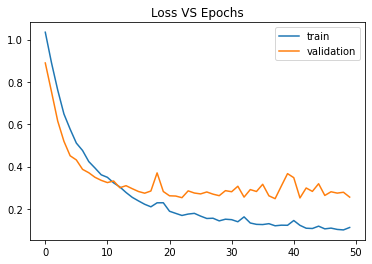

In [ ]:
epochs = history.epoch
loss = history.history["loss"]
val_loss = history.history["val_loss"]


plt.plot(epochs, loss, label="train")
plt.plot(epochs, val_loss, label="validation")

plt.legend()
plt.title("Loss VS Epochs")

plt.show()



**Observe**

Though RMSProp reaches minima within 10 training epochs:
- we see a lot of oscillations than Gradient Descent with momentum
- meaning the optimizer still takes steps in the direction not to the global minima


**Quiz**

```
If dw_q >>>> dw_p such that, the noisy steps of Gradient Descent increases then ?

1. RMSprop should be used
2. Gradient Descent with Momentum is to be used

```

**Answer**

1. RMSprop should be used

**Explanation**

During weight updation, RMSprop uses :
- $w^k = w^k - α \times \frac{dw^k}{\sqrt{V_{dw^k}+ ϵ} } $

With $V_{dw^k}$ in the denominator,
- $V_{dw_p} >>> V_{dw_q} $

Making the optimizer to have reduced noisy steps

#Adam

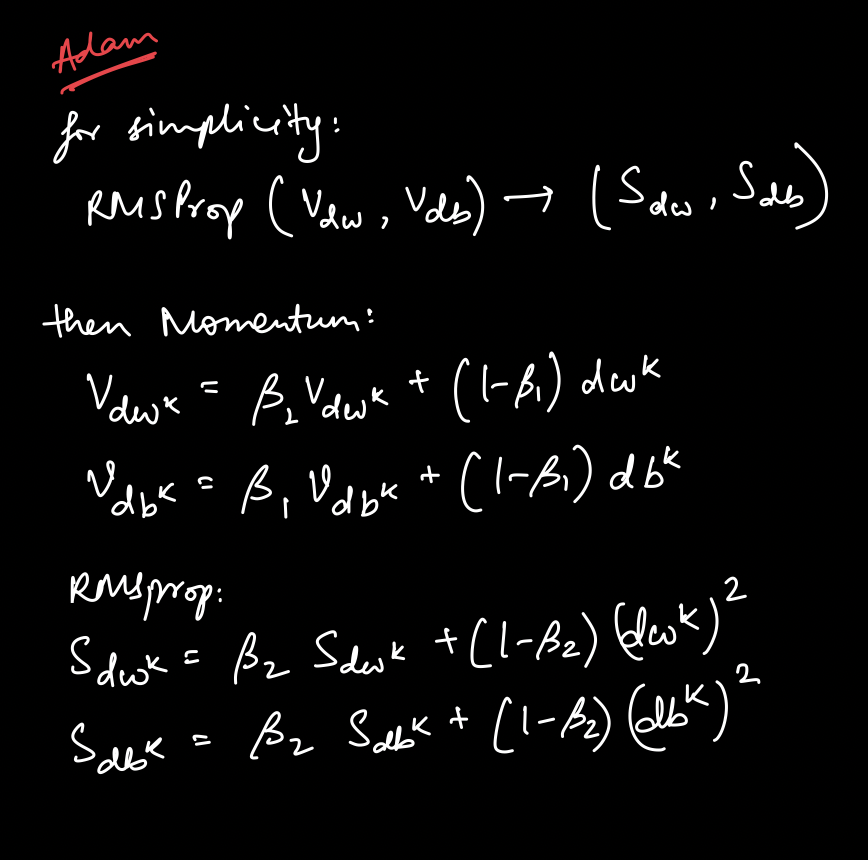

#### is there a way to reduce these oscillations while still keeping the training epochs low ?

Ans: if we combine both RMSprop and momentum, this is done by an alogrithm called **Adam**

<br>

#### How does Adam work ?
Ans: Now for simplicity:
- Lets call RMSprop $V_{dw}, V_{db}$ as $S_{dw}, S_{db}$

Therefore now for some iteration t:
- We compute $dW$, $db$

then for Momentum we can say:

- $V_{dw^k} = \beta_1 V_{dw^k} + (1-\beta_1) dw^k $

Similarly,
- $V_{db^k} = \beta_1 V_{db^k} + (1-\beta_1) db^k $

<br>


After performing momentum ,RMSprop is calculated as:
- $S_{dw^k} = \beta_2 S_{dw^k} + (1-\beta_2) (dw^k)^2 $

Similarly
- $S_{db^k} = \beta_2 S_{db^k} + (1-\beta_2) (db^k)^2 $

<br>




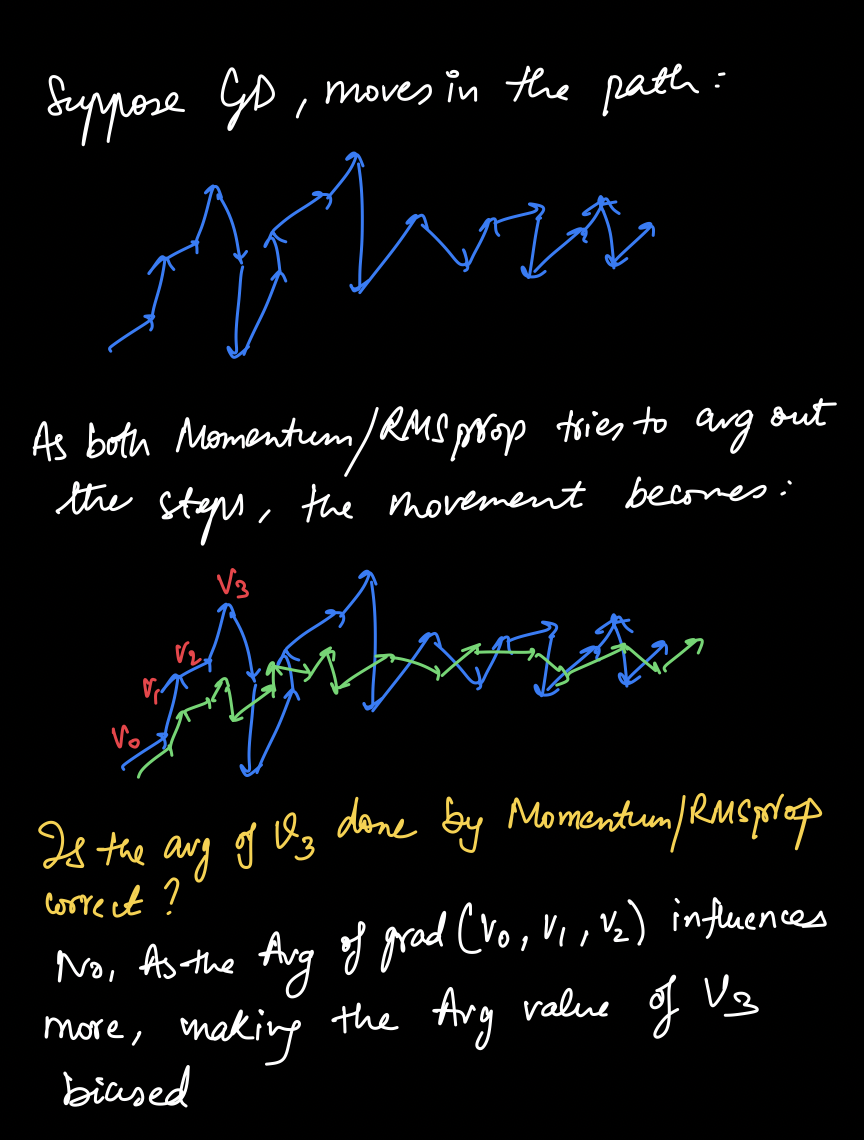

As momentum and RMSprop both averages out,  the steps taken by Optimizer,
- then for step:$V_3$, the average out value is more influenced by $V_0, V_1, V_2$
- which makes the average value of $V_3$ biased and far away from the actual $V_3$

<br>

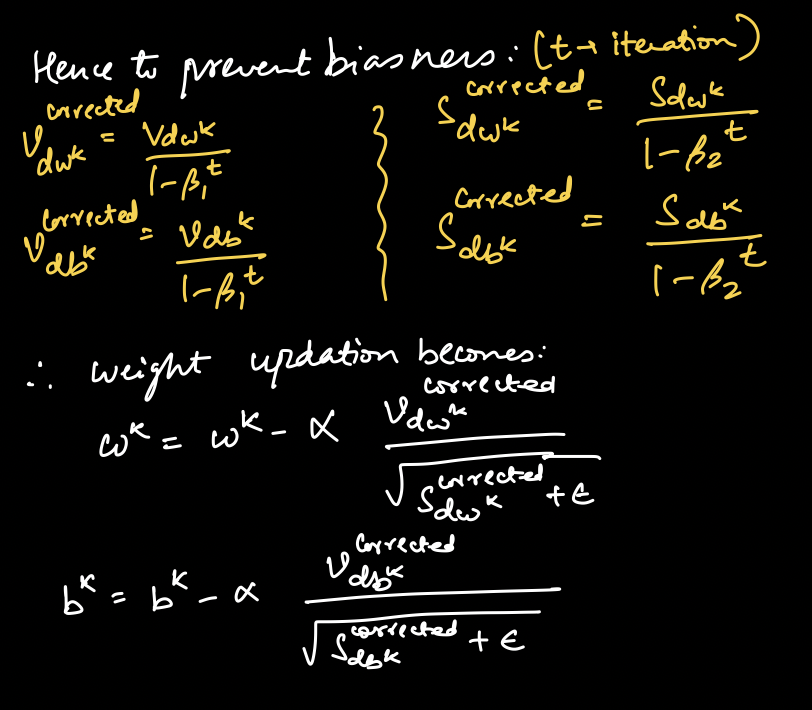




#### How to prevent this biasness ?
Ans: it is done by dividing $V_{dw^k}$, $V_{db^k}$ by:
- $V^{corrected}_{dw^k} = \frac{V_{dw^k}}{1-β_1^t}$

Similarly:
- $V^{corrected}_{db^k} = \frac{V_{db^k}}{1-β_1^t}$

and for RMSprop:

- $S^{corrected}_{dw^k} = \frac{S_{dw^k}}{1-β_2^t}$

Similarly:
- $S^{corrected}_{db^k} = \frac{S_{db^k}}{1-β_2^t}$

**Note:** this process is called as **Bias Correction**


<br>

Now finally, weights updation is performed:

- $w^k = w^k - α \times  \frac{1}{\sqrt{S^{corrected}_{dw}+ ϵ}} \times V^{corrected}_{dw}$

- $b^k = b^k - α \times  \frac{1}{\sqrt{S^{corrected}_{db}+ ϵ}} \times V^{corrected}_{db}$








Implementing Adam

In [ ]:
model_adam = create_baseline()

Using ```Adam``` as Optimizer

In [ ]:
model_adam.compile(optimizer = tf.keras.optimizers.Adam(beta_1 = 0.9, beta_2 = 0.999 ),
                loss = tf.keras.losses.CategoricalCrossentropy() )


Training the model with epoch = 50 and batch size = 128

In [ ]:
history = model_adam.fit(X_train, y_train, validation_data = (X_val, y_val),  epochs=50, batch_size=128, verbose = 0,callbcaks=[,])


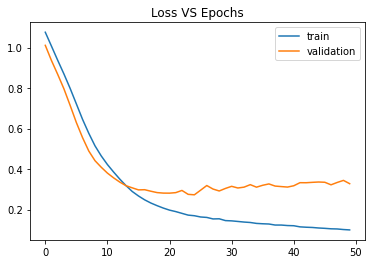

In [ ]:
epochs = history.epoch
loss = history.history["loss"]
val_loss = history.history["val_loss"]


plt.plot(epochs, loss, label="train")
plt.plot(epochs, val_loss, label="validation")

plt.legend()
plt.title("Loss VS Epochs")

plt.show()



**Quiz**

```
Which of the statment is true ?

S1. To make the average value for a step, not be influenced by the previous average values, bias Correction is added

S2. To make the average value for a step, be influenced by the previous average values, bias Correction is added


1. S1 is correct
2. S2 is correct

```

**Answer**

1. S1 is correct

#### Learning Rate Decay

**Observe**

How using Adam algorithm,
- the oscillations are reduced drastically
- also the model takes almost 12 epochs for it to show accruate results
- But the model performance on the validation is still high

<br>

#### Is there a way to improve model performance  ?

Ans: recall how optimizer tends on moving around the global minima:
- if the learning rate is high

#### Will a learning rate of 0.01 high for our problem ?
Ans: As using different Optimizers,
- The validation loss moves around 0.4
- it means the optimizer is stuck around the global minima


#### But what happens if learning rate is smaller ?
Ans: The number of steps increases
- And the model will require more epochs to reach global minima

<br>

#### How to make optimizer take small number of steps and still reach global minima ?

Ans: what if we keep a high learning rate intially ($\alpha_0$)
- and Learning rate decreases with each epoch($e$) by a rate $r_0$

This is called as Learning rate decay, defined as:
- for epoch in epochs:
- $\alpha = \frac{1}{1 + r_0 \times epoch } \times \alpha_0 $
- $\alpha_0 = \alpha $

<br>

#### When to implement Learning rate decay, should it be done before or after an epoch ?
Ans: After an epoch by using:
- Tensorflow callback

<br>

Lets now implement Learning Rate decay using [LearningRateScheduler](https://keras.io/api/callbacks/learning_rate_scheduler/)



In [ ]:
from tensorflow.keras.callbacks import LearningRateScheduler

defining the Learning Rate decay

In [ ]:
def scheduler(epoch, lr):
  r_0 = 0.01
  lr = (1/(1+r_0*epoch))*lr

  return lr

In [ ]:
LRdecay = LearningRateScheduler(scheduler)

In [ ]:
model_adam = create_baseline()

Using ```Adam``` as Optimizer

In [ ]:
model_adam.compile(optimizer = tf.keras.optimizers.Adam(beta_1 = 0.9, beta_2 = 0.999 ),
                loss = tf.keras.losses.CategoricalCrossentropy() )


Training the model with epoch = 50 and batch size = 128

In [ ]:
history = model_adam.fit(X_train, y_train, validation_data = (X_val, y_val),  epochs=50, batch_size=128,callbacks=[LRdecays], verbose = 0)


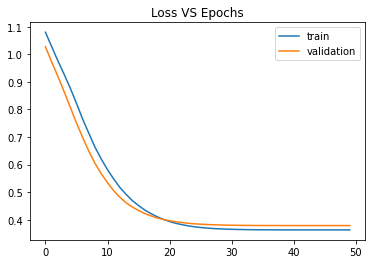

In [ ]:
epochs = history.epoch
loss = history.history["loss"]
val_loss = history.history["val_loss"]


plt.plot(epochs, loss, label="train")
plt.plot(epochs, val_loss, label="validation")

plt.legend()
plt.title("Loss VS Epochs")

plt.show()



**observe**

How by using Learning Rate decay,
- the model reaches a loss of around 0.3 now
- Showing that reducing the Learning Rate did help improve model performance




**Quiz**

```
if learning rate(alpha) = (1/(1 + r_0* epoch)) * alpha_0 , and alpha_0 = 0.1, epoch = 10 and r_0 = 0.1 then what is the value of alpha ?


1. 0.005
2. 0.5
3. 0.05

```

**Answer**

3. 0.05

**Explanation**

$\alpha = \frac{1}{1 + r_0 \times epoch } \times \alpha_0 $
- $\alpha = \frac{1}{1 + 0.1 \times 10 } \times 0.1 $
- $\alpha = \frac{1}{2} \times 0.1 $
- $\alpha = 0.5 \times 0.1  = 0.05$

**Assessments Covered**
- https://www.scaler.com/hire/test/problem/21611/

#Simulation for Momentum, RMSprop and Adam

<font color = 'red'>Instructor Note</font>

<img src=https://d2beiqkhq929f0.cloudfront.net/public_assets/assets/000/045/662/original/demo-surface_%281%29.gif?1693662781>

[Visualization software](https://github.com/lilipads/gradient_descent_viz) for simulation purpose
- **Works locally**

**observe**

- How momentum quickly reaches minima due to the exponential moving average


Also Adam takes a few iteration before reaching minima

- Showing how it uses both the RMSprop and Momentum in order to find the global minima

